In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import os
import glob

from config import config
from utils import (
    preprocess_img,
    is_valid_image,
    build_nan_pixel_mask,
    build_pixel_outlier_mask,
)


Showing 5 random samples this run.

================ 10thRamadanSouth_g12 ================

Image quality:
NaN pixels: 0 / 104,146 (0.00%)
Dark pixels: 0 (0.00%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 4 (0.00%)
Pixels excluded by preprocessing: 0 (0.00%)
Processed mask changed pixels: 0
Brightness (12-band mean):
Mean/p05/p50/p95: 0.3207 / 0.1997 / 0.3247 / 0.4274
Mask distribution (raw):
Raw 1: 4,010
Raw 2: 79,577
Raw 4: 20,559
Mask distribution (processed):
Greenery (1): 4,010
Sand (2): 79,577
Cement (4): 20,559


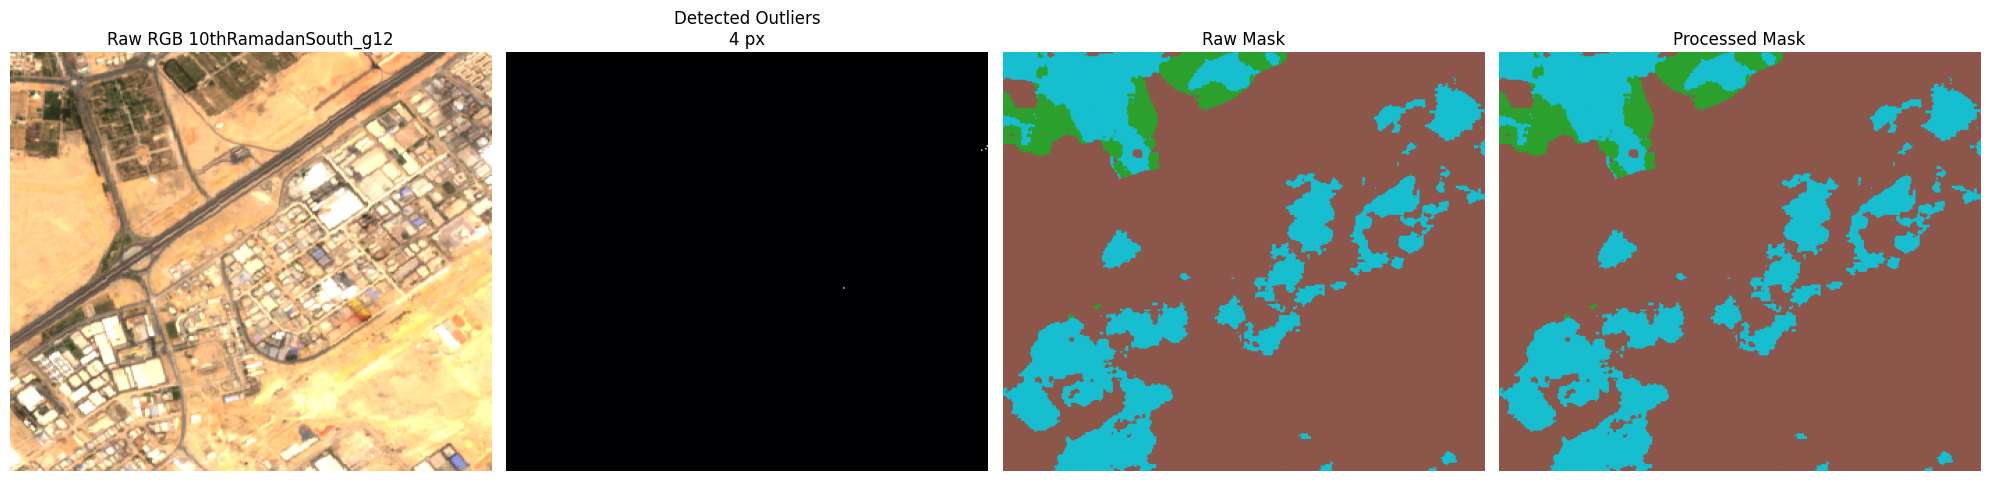


================ Damietta_g20 ================

Image quality:
NaN pixels: 0 / 105,700 (0.00%)
Dark pixels: 2,423 (2.29%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 0 (0.00%)
Pixels excluded by preprocessing: 0 (0.00%)
Processed mask changed pixels: 0
Brightness (12-band mean):
Mean/p05/p50/p95: 0.2024 / 0.1183 / 0.1999 / 0.2886
Mask distribution (raw):
Raw 1: 32,546
Raw 2: 1,062
Raw 3: 3,991
Raw 4: 68,101
Mask distribution (processed):
Greenery (1): 32,546
Sand (2): 1,062
Water (3): 3,991
Cement (4): 68,101


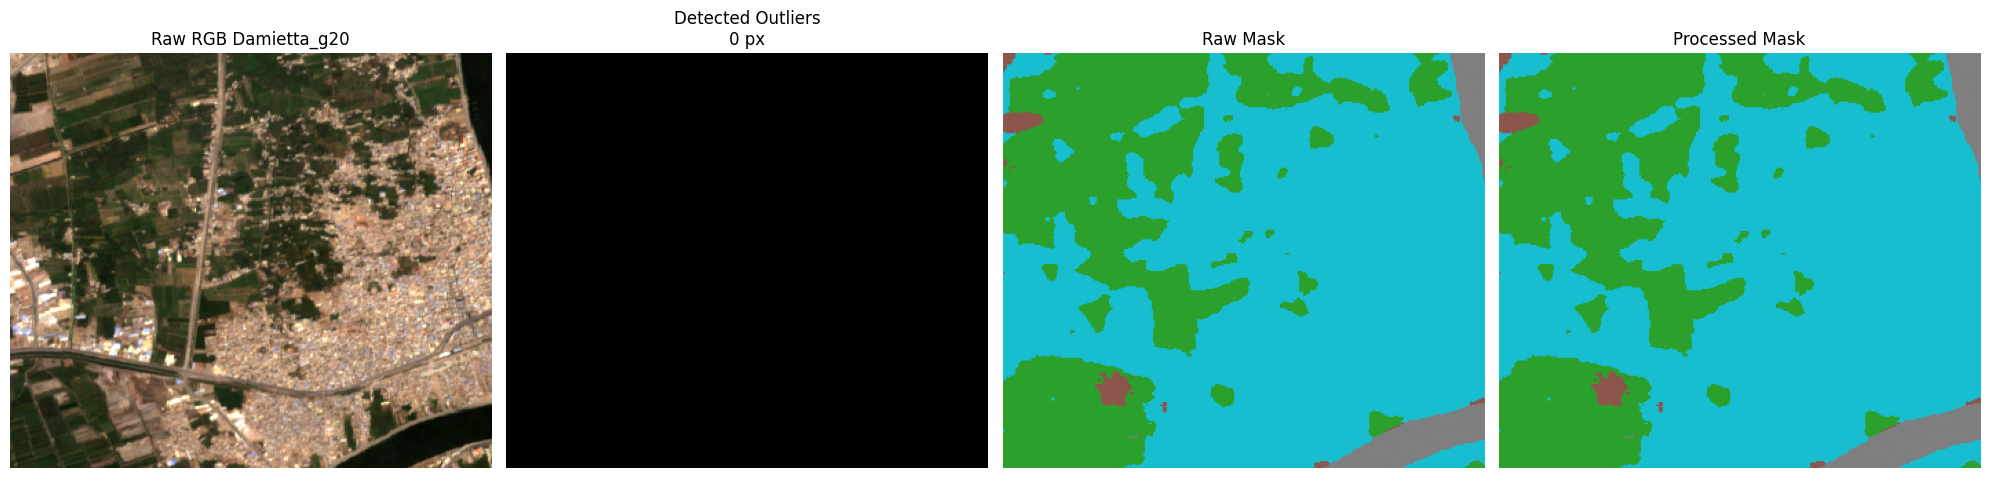


================ SidiBarrani_g21 ================

Image quality:
NaN pixels: 351 / 106,002 (0.33%)
Dark pixels: 351 (0.33%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 0 (0.00%)
Pixels excluded by preprocessing: 0 (0.00%)
Processed mask changed pixels: 0
Brightness (12-band mean):
Mean/p05/p50/p95: 0.0902 / 0.0558 / 0.0954 / 0.1104
Mask distribution (raw):
Raw 0: 351
Raw 2: 51,417
Raw 3: 54,232
Raw 4: 2
Mask distribution (processed):
Unknown (0): 351
Sand (2): 51,417
Water (3): 54,232
Cement (4): 2


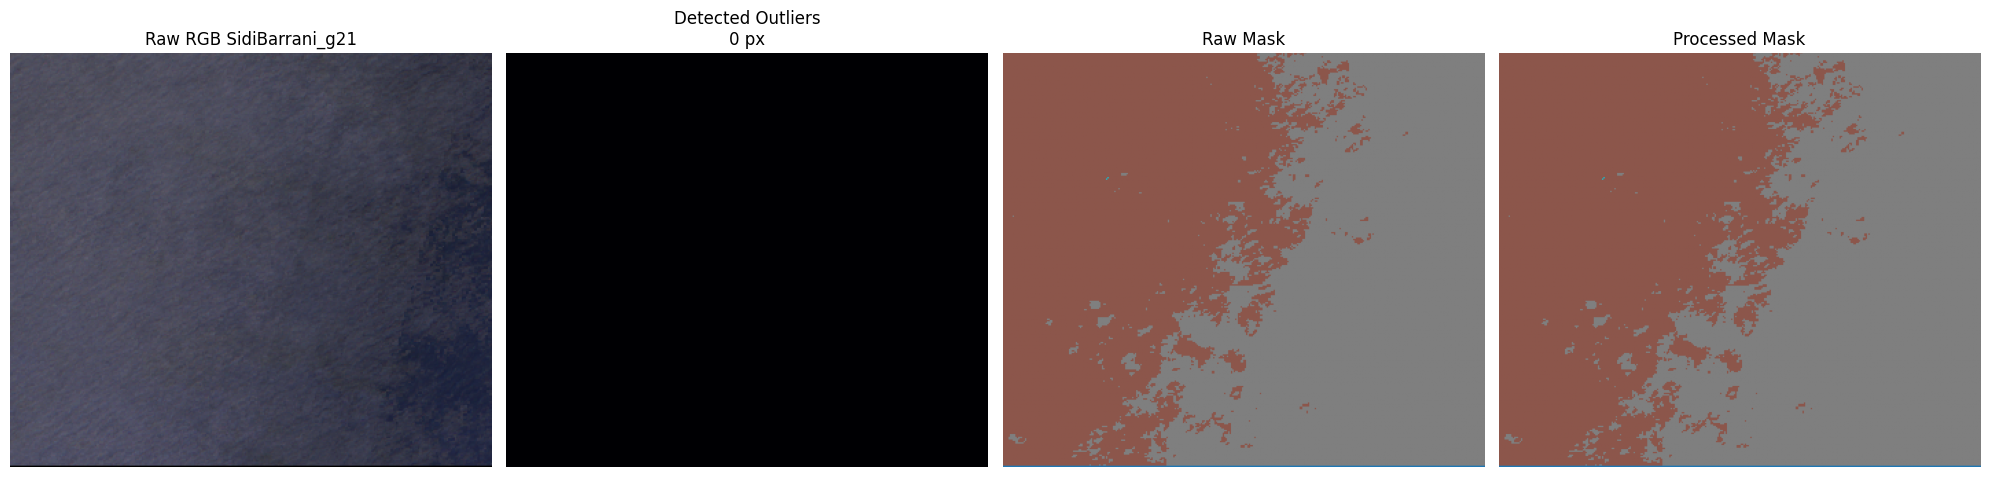


================ Ismailia_g03 ================

Image quality:
NaN pixels: 0 / 104,447 (0.00%)
Dark pixels: 0 (0.00%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 1 (0.00%)
Pixels excluded by preprocessing: 0 (0.00%)
Processed mask changed pixels: 2
Brightness (12-band mean):
Mean/p05/p50/p95: 0.2027 / 0.0332 / 0.0822 / 0.4741
Mask distribution (raw):
Raw 0: 4
Raw 1: 35
Raw 2: 44,514
Raw 3: 57,843
Raw 4: 2,051
Mask distribution (processed):
Unknown (0): 2
Greenery (1): 35
Sand (2): 44,516
Water (3): 57,843
Cement (4): 2,051


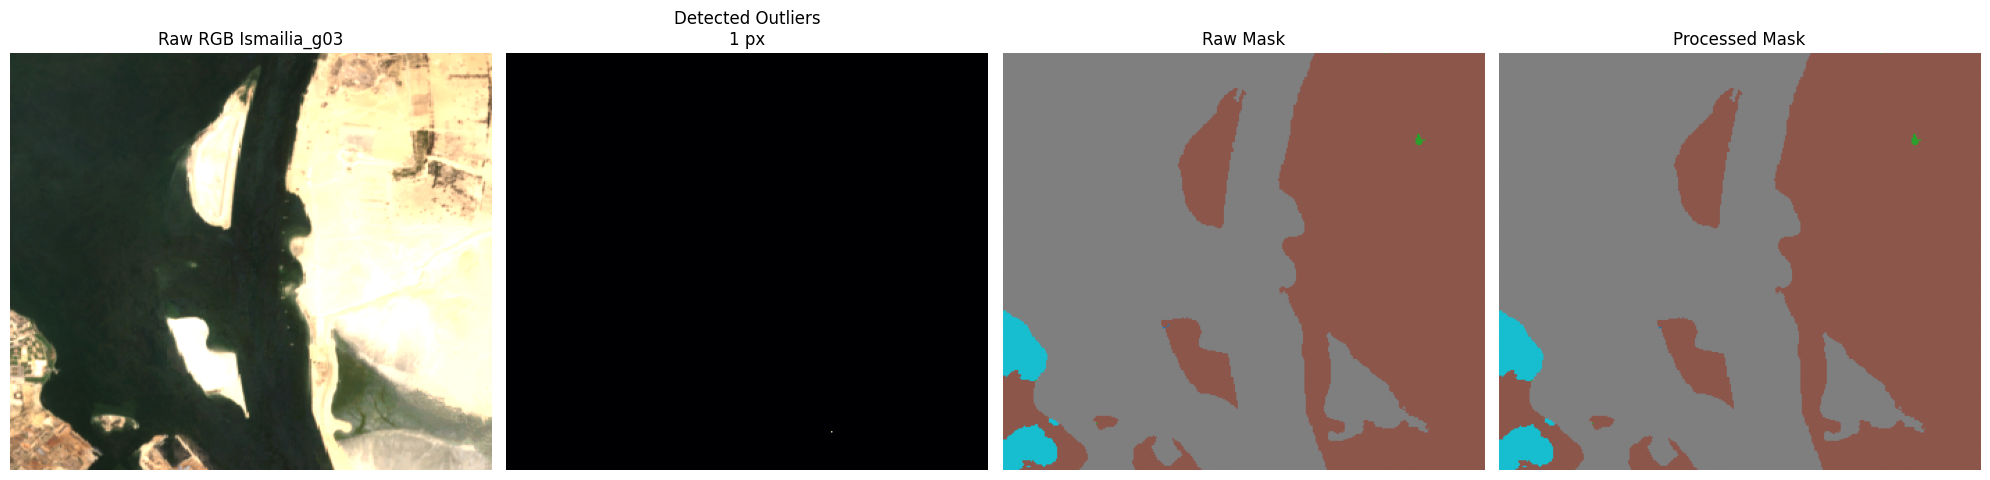


================ 10thRamadanSouth_g21 ================

Image quality:
NaN pixels: 0 / 104,146 (0.00%)
Dark pixels: 0 (0.00%)
Bright/saturated pixels: 0 (0.00%)
Outlier pixels detected: 0 (0.00%)
Pixels excluded by preprocessing: 0 (0.00%)
Processed mask changed pixels: 0
Brightness (12-band mean):
Mean/p05/p50/p95: 0.3033 / 0.2348 / 0.2979 / 0.3826
Mask distribution (raw):
Raw 1: 76
Raw 2: 29,643
Raw 3: 73
Raw 4: 74,354
Mask distribution (processed):
Greenery (1): 76
Sand (2): 29,643
Water (3): 73
Cement (4): 74,354


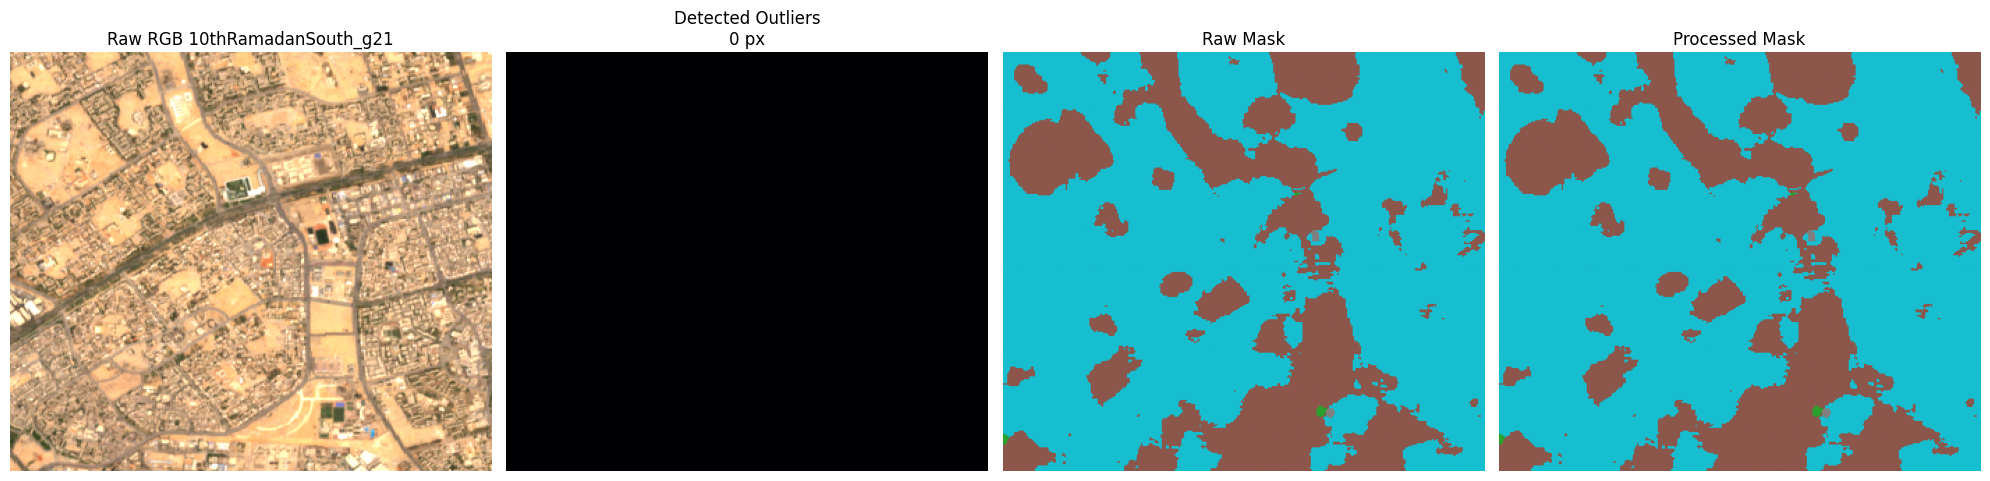

In [ ]:
IMG_DIR = "./data/samples/imgs"
MASK_DIR = "./data/samples/masks"

img_paths = sorted(set(glob.glob(os.path.join(IMG_DIR, "*_Spectral_300px.tif")) + glob.glob(os.path.join(IMG_DIR, "*_Spectral.tif"))))
num_samples = min(5, len(img_paths))
selected_img_paths = np.random.default_rng().choice(img_paths, size=num_samples, replace=False)
print(f"Showing {num_samples} random samples this run.")

for img_path in selected_img_paths:
    sample_name = os.path.basename(img_path).replace("_Spectral_300px.tif", "").replace("_Spectral.tif", "")
    mask_path = os.path.join(MASK_DIR, f"{sample_name}_Mask_300px.tif")
    if not os.path.exists(mask_path):
        mask_path = os.path.join(MASK_DIR, f"{sample_name}_Mask.tif")

    if not os.path.exists(mask_path):
        print(f"Missing mask for {img_path}, skipping...")
        continue

    if not is_valid_image(img_path):
        print(f"Skipping high-NaN image (>=95% NaN pixels): {img_path}")
        continue

    print(f"\n================ {sample_name} ================\n")

    # -------- Load raw image + mask --------
    with rasterio.open(img_path) as src:
        raw_img = src.read().astype(np.float32)
    with rasterio.open(mask_path) as src:
        raw_mask = src.read(1)

    h = min(raw_img.shape[1], raw_mask.shape[0])
    w = min(raw_img.shape[2], raw_mask.shape[1])
    raw_img = raw_img[:, :h, :w]
    raw_mask = raw_mask[:h, :w]

    nan_pixels = build_nan_pixel_mask(raw_img)
    raw_img_scaled = np.clip(np.nan_to_num(raw_img, nan=0.0), 0, 10000) / 10000.0
    bands = raw_img_scaled[:12]
    band_mean = np.mean(bands, axis=0)
    band_max = np.max(bands, axis=0)
    saturated_band_count = np.sum(bands >= config.SATURATED_BAND_THRESHOLD, axis=0)
    dark_pixels = (
        (band_mean <= config.DARK_PIXEL_MEAN_THRESHOLD)
        & (band_max <= config.DARK_PIXEL_MAX_THRESHOLD)
    )
    bright_pixels = (
        (band_mean >= config.BRIGHT_PIXEL_MEAN_THRESHOLD)
        | (saturated_band_count >= config.MAX_SATURATED_BANDS)
    )
    outlier_pixels = build_pixel_outlier_mask(bands)

    # -------- Shared preprocessing path --------
    img, processed_mask, pixel_valid = preprocess_img(img_path, mask_path, train=False)

    # -------- RGB for display --------
    rgb_raw = np.transpose(raw_img_scaled[[3, 2, 1]], (1, 2, 0))
    rgb_raw = np.clip(rgb_raw * 3.0, 0, 1)

    # -------- Stats --------
    raw_values, raw_counts = np.unique(raw_mask, return_counts=True)
    processed_values, processed_counts = np.unique(processed_mask, return_counts=True)
    brightness_valid = ~nan_pixels
    raw_brightness = band_mean[brightness_valid]

    print("Image quality:")
    print(f"NaN pixels: {int(nan_pixels.sum()):,} / {nan_pixels.size:,} ({100 * nan_pixels.mean():.2f}%)")
    print(f"Dark pixels: {int(dark_pixels.sum()):,} ({100 * dark_pixels.mean():.2f}%)")
    print(f"Bright/saturated pixels: {int(bright_pixels.sum()):,} ({100 * bright_pixels.mean():.2f}%)")
    print(f"Outlier pixels detected: {int(outlier_pixels.sum()):,} ({100 * outlier_pixels.mean():.2f}%)")
    print(f"Pixels excluded by preprocessing: {int((~pixel_valid).sum()):,} ({100 * (~pixel_valid).mean():.2f}%)")
    print(f"Processed mask changed pixels: {int((raw_mask != processed_mask).sum()):,}")

    if raw_brightness.size > 0:
        print("Brightness (12-band mean):")
        print(
            f"Mean/p05/p50/p95: {raw_brightness.mean():.4f} / "
            f"{np.percentile(raw_brightness, 5):.4f} / {np.percentile(raw_brightness, 50):.4f} / {np.percentile(raw_brightness, 95):.4f}"
        )

    print("Mask distribution (raw):")
    for value, count in zip(raw_values, raw_counts):
        print(f"Raw {int(value)}: {count:,}")

    print("Mask distribution (processed):")
    for value, count in zip(processed_values, processed_counts):
        class_name = config.CLASS_NAMES.get(int(value), "Unknown")
        print(f"{class_name} ({int(value)}): {count:,}")

    # -------- Visualization --------
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].set_title(f"Raw RGB {sample_name}")
    axes[0].imshow(rgb_raw)
    axes[0].axis("off")

    axes[1].set_title(f"Detected Outliers\n{int(outlier_pixels.sum()):,} px")
    axes[1].imshow(outlier_pixels, cmap="magma")
    axes[1].axis("off")

    axes[2].set_title("Raw Mask")
    axes[2].imshow(raw_mask, cmap="tab10", vmin=0, vmax=4)
    axes[2].axis("off")

    axes[3].set_title("Processed Mask")
    axes[3].imshow(processed_mask, cmap="tab10", vmin=0, vmax=4)
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()
